In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 

# Data preprocessing

## Import dataset

In [2]:
def messy_vol_acidity(value:str):
    choice = np.random.randint(0, 3)
    if choice == 0: # clean string volatile acidity
        return value
    elif choice == 1: # replace decimal point with comma
        return value.replace('.', ',')
    else: # add volatile acidity units
        return f'{value} g/L'

def make_dirty(df: pd.DataFrame):
    np.random.seed(1)
    dirty = df.copy()
    
    # Casts volatile acidity and quality columns to string
    dirty['volatile acidity'] = dirty['volatile acidity'].astype(str)
    dirty['quality'] = dirty['quality'].astype(str)
    
    
    # inconsistent string format
    dirty['volatile acidity'] = dirty['volatile acidity'].apply(messy_vol_acidity)
    
    # add random duplicates rows (approx. 2% of the data)
    dup_indices = np.random.choice(dirty.index, size=32, replace=False) # indices of rows to duplicate    
    dup_rows = dirty.iloc[dup_indices]
    
    dirty = pd.concat(objs=[dirty, dup_rows]).reset_index(drop=True)
    
    # add NaNs across 2% of values to 4 columns (pH, alcohol, total sulfure dioxide, and residual sugar)
    for col in ['pH', 'alcohol', 'total sulfur dioxide', 'residual sugar']:
        s = int(np.ceil(len(dirty.index)*0.02))
        nan_indices = np.random.choice(dirty.index, size=s, replace=False) # indices of rows to NaN
        dirty.loc[nan_indices, col] = None

    
    # adds inconsistent column name format (extra spaces)
    dirty.columns = dirty.columns.str.replace(' ', '   ')
    
    # add column values to quality column that can be mapped to existing values (2% of rows)
    qual_map = {
        '1': 'one',
        '2': 'two',
        '3': 'three',
        '4': 'four',
        '5': 'five',
        '6': 'six',
        '7': 'seven',
        '8': 'eight',
        '9': 'nine',
        '10': 'ten',
    }
    
    s = int(np.ceil(len(dirty.index)*0.02))
    qual_indices = np.random.choice(dirty.index, size=s, replace=False) # indices of rows to convert to text based num
    
    dirty.loc[qual_indices, 'quality'] = dirty.loc[qual_indices, 'quality'].map(qual_map)

    return dirty, dup_indices

In [3]:
wine_df, _ = make_dirty(pd.read_csv('./winequality-red.csv'))

wine_df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,"0,7",0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,"0,28",0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,"0,7",0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,NaN,0.56,9.4,5
6,7.9,0.6,0.06,1.6,0.069,15.0,NaN,0.9964,3.30,0.46,9.4,5
7,7.3,"0,65",0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,"0,5",0.36,NaN,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [4]:
print("Shape:", wine_df.shape, '\n')

print(f'Columns: \n{",".join(wine_df.columns.tolist())}\n')

wine_df.info()

Shape: (1631, 12) 

Columns: 
fixed   acidity,volatile   acidity,citric   acid,residual   sugar,chlorides,free   sulfur   dioxide,total   sulfur   dioxide,density,pH,sulphates,alcohol,quality

<class 'pandas.DataFrame'>
RangeIndex: 1631 entries, 0 to 1630
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   fixed   acidity           1631 non-null   float64
 1   volatile   acidity        1631 non-null   str    
 2   citric   acid             1631 non-null   float64
 3   residual   sugar          1598 non-null   float64
 4   chlorides                 1631 non-null   float64
 5   free   sulfur   dioxide   1631 non-null   float64
 6   total   sulfur   dioxide  1598 non-null   float64
 7   density                   1631 non-null   float64
 8   pH                        1598 non-null   float64
 9   sulphates                 1631 non-null   float64
 10  alcohol                   1598 non-null   floa

In [5]:
wine_df.isna().sum()

fixed   acidity              0
volatile   acidity           0
citric   acid                0
residual   sugar            33
chlorides                    0
free   sulfur   dioxide      0
total   sulfur   dioxide    33
density                      0
pH                          33
sulphates                    0
alcohol                     33
quality                      0
dtype: int64

In [6]:
wine_df.duplicated().sum()

np.int64(95)

In [7]:
wine_df['volatile   acidity'].unique().tolist()

['0,7',
 '0.88',
 '0.76',
 '0,28',
 '0.66',
 '0.6',
 '0,65',
 '0.58',
 '0,5',
 '0.5 g/L',
 '0,615',
 '0.61 g/L',
 '0.62',
 '0.62 g/L',
 '0.56 g/L',
 '0.59',
 '0.32',
 '0.22 g/L',
 '0.39',
 '0,43',
 '0.49 g/L',
 '0.4 g/L',
 '0,41',
 '0.71 g/L',
 '0.645',
 '0.675 g/L',
 '0,685',
 '0,655',
 '0,605',
 '0,32',
 '0.645 g/L',
 '0,6',
 '0,38',
 '1.13',
 '0.45',
 '0,45',
 '0.61',
 '0.49',
 '0,66',
 '0.67 g/L',
 '0,52',
 '0.935',
 '0.29 g/L',
 '0,31',
 '0.5',
 '0.38',
 '0,51',
 '0.42 g/L',
 '0.63',
 '0,39',
 '0,4',
 '0.69 g/L',
 '0.52',
 '0.735',
 '0,725',
 '0.725 g/L',
 '0.52 g/L',
 '0,705',
 '0.705 g/L',
 '0,63',
 '0,69',
 '0.675',
 '0.41 g/L',
 '0.785',
 '0.75',
 '0.625 g/L',
 '0.45 g/L',
 '0.3 g/L',
 '0.55 g/L',
 '0,62',
 '0,49',
 '1,02',
 '0.6 g/L',
 '0.775',
 '0.9 g/L',
 '0.545 g/L',
 '0,545',
 '0.575',
 '0,33',
 '0,56',
 '0.31 g/L',
 '0.56',
 '0.54 g/L',
 '0,55',
 '1.07',
 '0.695',
 '0.71',
 '1,33',
 '1.33 g/L',
 '0.745',
 '1.04',
 '0.715 g/L',
 '0.415 g/L',
 '0,745',
 '0.34 g/L',
 '0.39 

In [8]:
wine_df['quality'].unique().tolist()

['5', '6', '7', '4', 'six', 'five', '8', '3', 'eight', 'four', 'seven']

## Clean Data (parse and organize)

In [9]:
# fix column name format
wine_df.columns = wine_df.columns.str.replace(r'\s+', ' ', regex=True)

# map string qualities to numbers and cast column to numeric
qual_map = {
    'one': '1',
    'two': '2',
    'three': '3',
    'four': '4',
    'five': '5',
    'six': '6',
    'seven': '7',
    'eight': '8',
    'nine': '9',
    'ten': '10',
}

wine_df['quality'] = wine_df['quality'].replace(qual_map)
wine_df['quality'] = wine_df['quality'].astype(int)

# normalize format of volatile acidity and cast column to numeric
def clean_vol_acidity(value:str):
    return value.replace(',', '.').replace('g/L', '').strip()

wine_df['volatile acidity'] = wine_df['volatile acidity'].apply(clean_vol_acidity)
wine_df['volatile acidity'] = wine_df['volatile acidity'].astype(float)

# Drop duplicate rows
wine_df.drop_duplicates(inplace=True)

# impute NaNs with median of known values
for col in ['residual sugar', 'total sulfur dioxide', 'pH', 'alcohol']:
    wine_df[col] = wine_df[col].fillna(wine_df[col].median())

wine_df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.31,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,38.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,2.2,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
10,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5


# Data Exploration & Summary Statistics

In [17]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000,1398.000000
mean,8.308941,0.528516,0.271488,2.513233,0.087806,15.880544,46.669170,0.996717,3.310837,0.657933,10.421757,5.625894
std,1.741333,0.181708,0.194873,1.327447,0.048752,10.386967,32.972497,0.001870,0.153329,0.169329,1.068144,0.820000
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997827,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


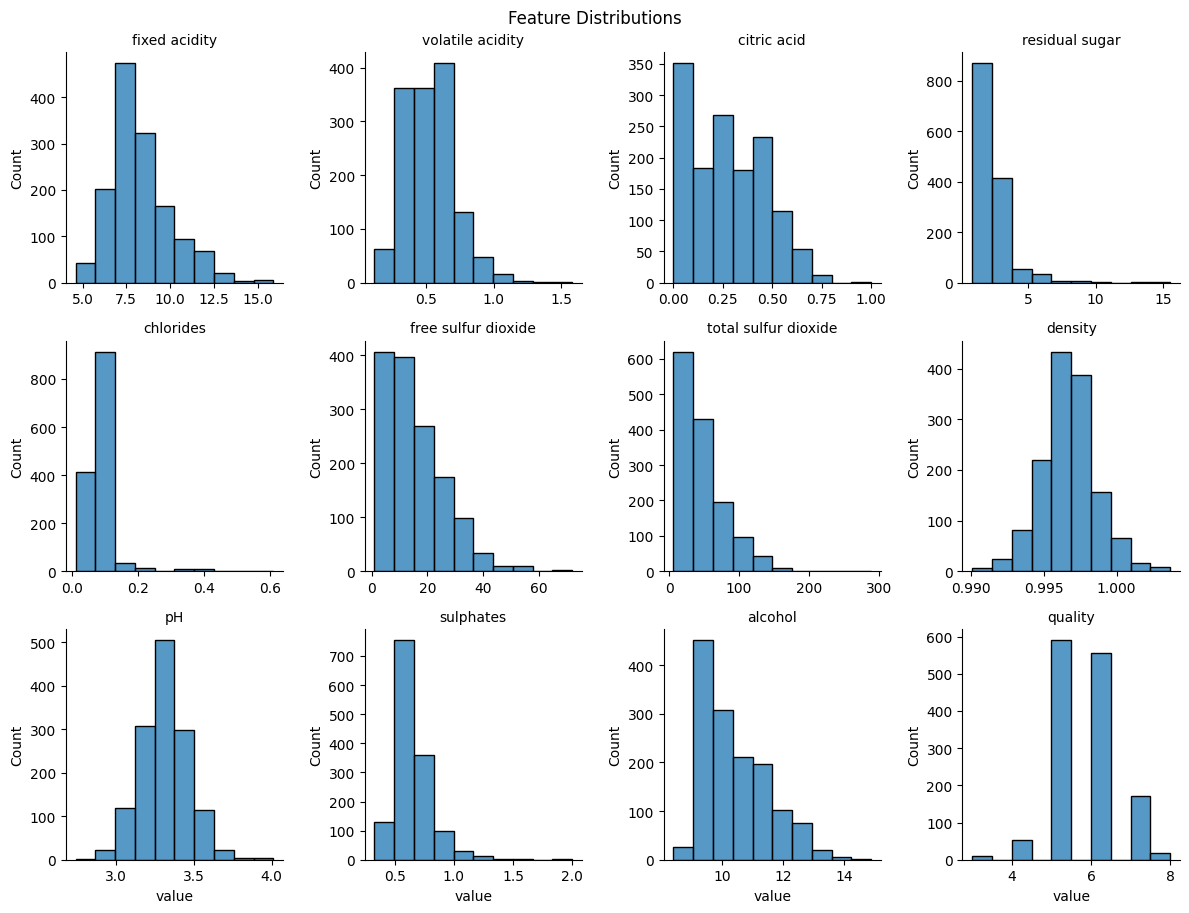

In [ ]:
wine_df.head() # wide data format, needs to be in long format to plot with seaborn

wine_long = wine_df.melt(var_name='feature')

g = sns.FacetGrid(wine_long, col='feature', col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", bins=10)

g.set_titles(col_template='{col_name}')

plt.suptitle('Feature Distributions', y=1.01)

plt.show()

# Most distributions are not normal --> Use non-parametric tests

## Spearman correlation matrix